In [60]:
import pandas as pd
import numpy as np
import statsmodels as statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats

# wypisanie informacji o danych

In [35]:
data = pd.read_csv("data.csv")
data

,Subject,Age (years),Gender,SBP (mm Hg),Heart rate (bpm),Smoking,Chest pain symptoms,Race,Treatment,CAD present?,CAD-free time (days),Hospital
0,1,65.6,Male,150,79,Past,Typical chest pain,White,Intervention,Yes,1313,Hospital A
1,2,66.7,Male,184,81,Past,No chest pain,White,Control,Yes,1081,Hospital A
2,3,67.6,Male,118,96,Never,No chest pain,White,Control,No,1657,Hospital A
3,4,67.7,Male,117,89,Past,Typical chest pain,White,Control,Yes,542,Hospital A
4,5,65.7,Male,147,73,Never,No chest pain,White,Control,Yes,738,Hospital A
...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,68.3,Male,215,70,Never,No chest pain,White,Intervention,No,1578,Hospital C
396,397,68.3,Male,124,52,Past,Atypical chest pain,White,Control,No,1622,Hospital C
397,398,72.1,Male,155,51,Current,No chest pain,Other,Intervention,No,1657,Hospital C
398,399,66.1,Female,166,95,Never,Nonanginal pain,Black,Control,No,1657,Hospital C


In [36]:
data.shape

(400, 12)

In [37]:
data.columns

Index(['Subject', 'Age (years)', 'Gender', 'SBP (mm Hg)', 'Heart rate (bpm)',
       'Smoking', 'Chest pain symptoms', 'Race', 'Treatment', 'CAD present?',
       'CAD-free time (days)', 'Hospital'],
      dtype='object')

In [38]:
for column in data.columns:
    print(f"Opis kolumny: {column}")
    print(data[column].describe())
    print(f"min:{min(data[column])}")
    print(f"\n")

Opis kolumny: Subject
count    400.000000
mean     200.500000
std      115.614301
min        1.000000
25%      100.750000
50%      200.500000
75%      300.250000
max      400.000000
Name: Subject, dtype: float64
min:1


Opis kolumny: Age (years)
count    400.000000
mean      66.058750
std        3.068838
min       58.100000
25%       63.875000
50%       66.100000
75%       68.300000
max       74.100000
Name: Age (years), dtype: float64
min:58.1


Opis kolumny: Gender
count      400
unique       2
top       Male
freq       271
Name: Gender, dtype: object
min:Female


Opis kolumny: SBP (mm Hg)
count    400.000000
mean     154.285000
std       26.245969
min       90.000000
25%      137.000000
50%      154.000000
75%      171.000000
max      229.000000
Name: SBP (mm Hg), dtype: float64
min:90


Opis kolumny: Heart rate (bpm)
count    400.000000
mean      74.072500
std       14.522206
min       50.000000
25%       63.000000
50%       74.000000
75%       84.000000
max      115.000000
Name: H

(array([ 5., 17., 46., 58., 71., 76., 60., 46., 15.,  6.]),
 array([58.1, 59.7, 61.3, 62.9, 64.5, 66.1, 67.7, 69.3, 70.9, 72.5, 74.1]),
 <BarContainer object of 10 artists>)

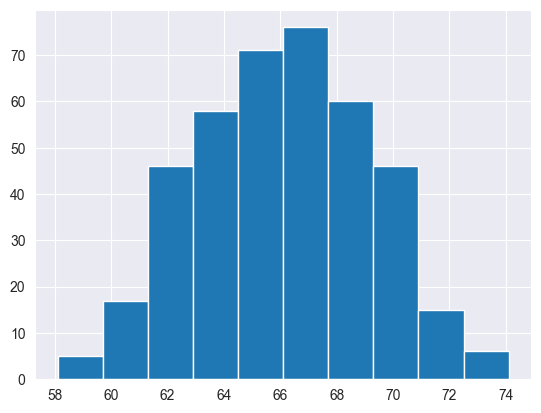

In [39]:
plt.hist(data['Age (years)'])

(array([271.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 129.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

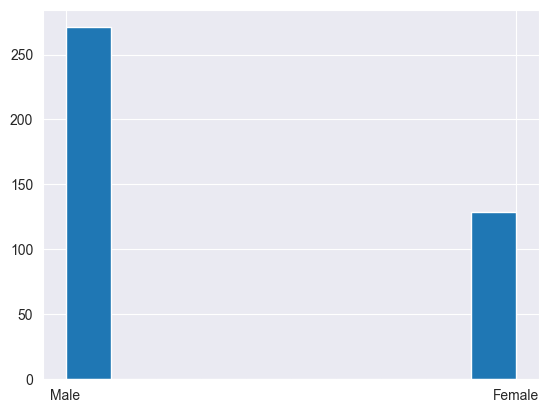

In [40]:
plt.hist(data['Gender'])

(array([133.,   0.,   0.,   0.,   0., 133.,   0.,   0.,   0., 134.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

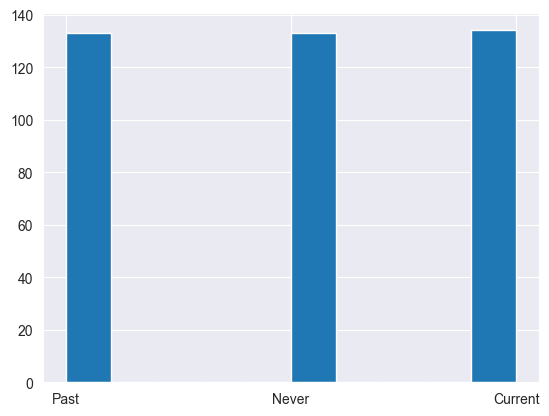

In [41]:
plt.hist(data['Smoking'])

(array([58., 38., 58., 60., 75., 43., 29., 30.,  7.,  2.]),
 array([ 50. ,  56.5,  63. ,  69.5,  76. ,  82.5,  89. ,  95.5, 102. ,
        108.5, 115. ]),
 <BarContainer object of 10 artists>)

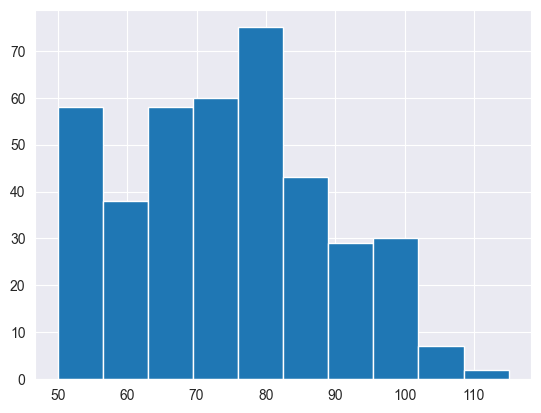

In [42]:
plt.hist(data['Heart rate (bpm)'])

(array([ 73.,   0.,   0., 124.,   0.,   0., 110.,   0.,   0.,  93.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

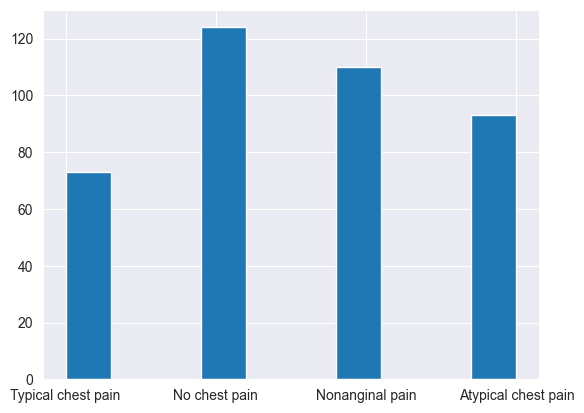

In [43]:
plt.hist(data['Chest pain symptoms'])

(array([281.,   0.,   0.,  41.,   0.,   0.,  33.,   0.,   0.,  45.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

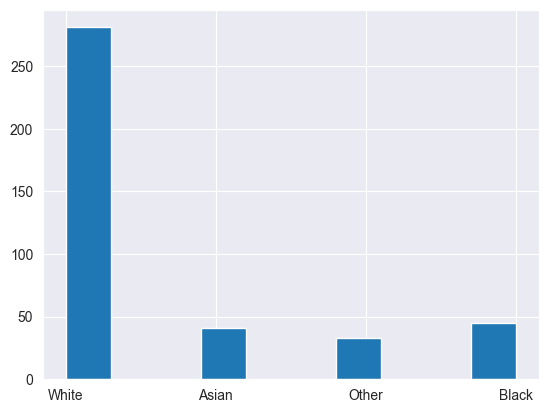

In [44]:
plt.hist(data['Race'])

(array([205.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 195.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

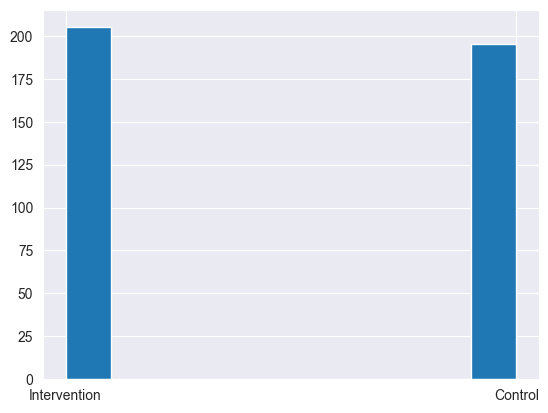

In [45]:
plt.hist(data['Treatment'])

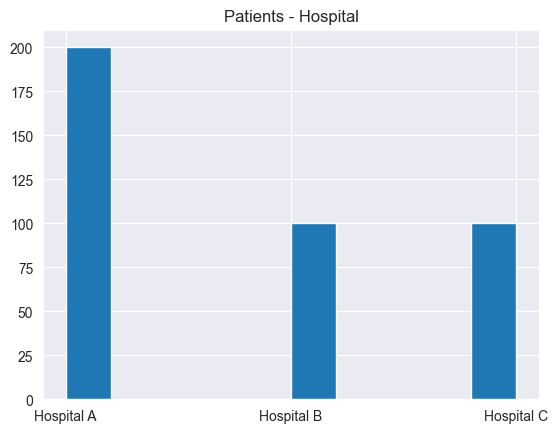

In [46]:
plt.hist(data['Hospital'])
plt.title('Patients - Hospital')
plt.show()


(array([204.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 196.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

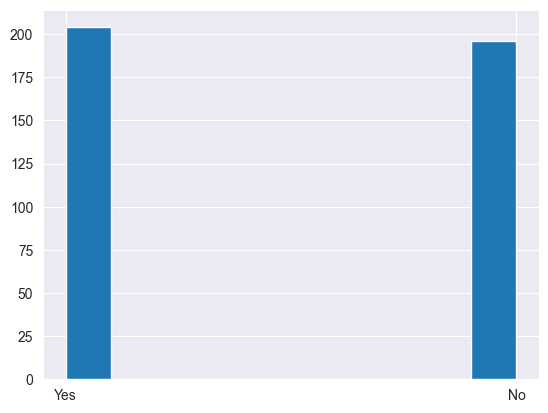

In [47]:
plt.hist(data['CAD present?'])

(array([ 16.,  24.,  29.,  39.,  37.,  22.,  16.,  18.,  19., 180.]),
 array([  30. ,  192.7,  355.4,  518.1,  680.8,  843.5, 1006.2, 1168.9,
        1331.6, 1494.3, 1657. ]),
 <BarContainer object of 10 artists>)

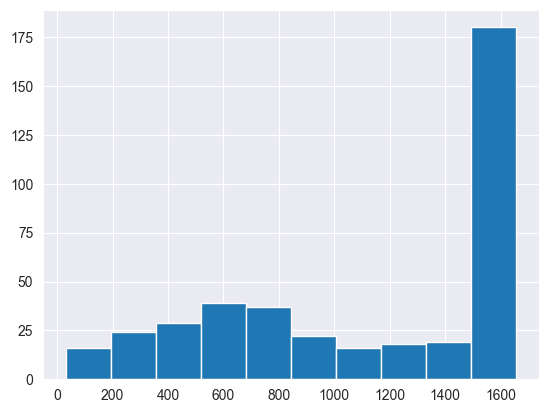

In [48]:
plt.hist(data['CAD-free time (days)'])

## Co wiemy ?
- Przeprowadzono 400 badań na 400 pacjentach
- Przedział wiekowy: 58 - 74 lat
- Przewaga mężczyzn o 100 osobników
- Równy podział między byłymi, palaczami, i nie palaczami
- Białasi dominują jest ich 250 reszta po 50 są inne rasy
- jest idealny podział między grupą interwencyjną a kontrolną
- badanie odbywało się w 3 szpitalach
- jest idealny podział pół na pół ludzi z CAD i bez
- czas wolny od CAD najczęstsza występująca wartość to 1600
- badanie jest multicentrowe odbywały się w trzech szpitalach


# Co chcemy sprawdzić ?

## Dla SBP i heart rate zrobić dla każdego 2 box ploty w zależności od CAD

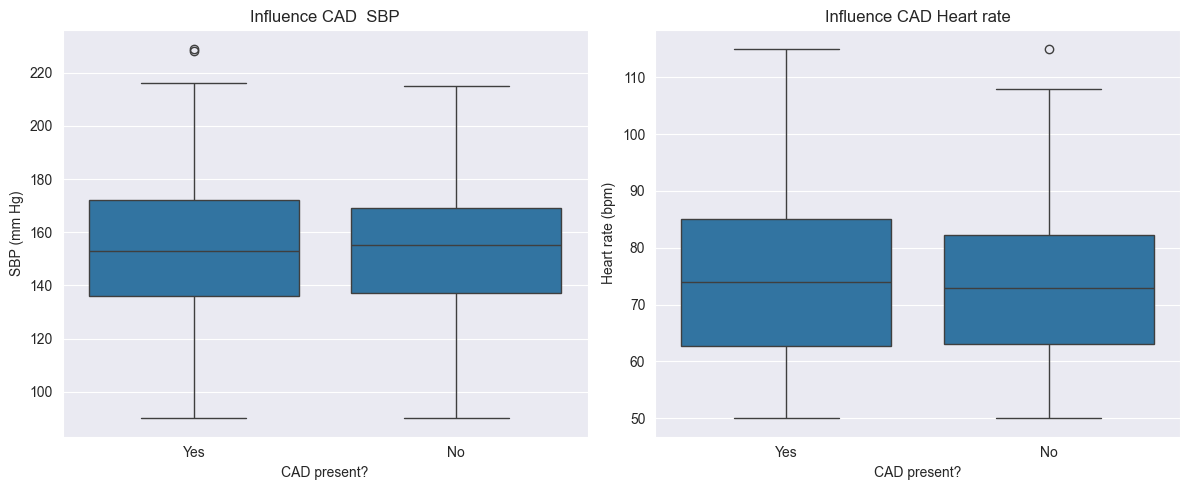

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=data, x='CAD present?', y='SBP (mm Hg)', ax=axes[0]).set_title('Influence CAD  SBP')
sns.boxplot(data=data, x='CAD present?', y='Heart rate (bpm)', ax=axes[1]).set_title('Influence CAD Heart rate')

plt.tight_layout()
plt.show()

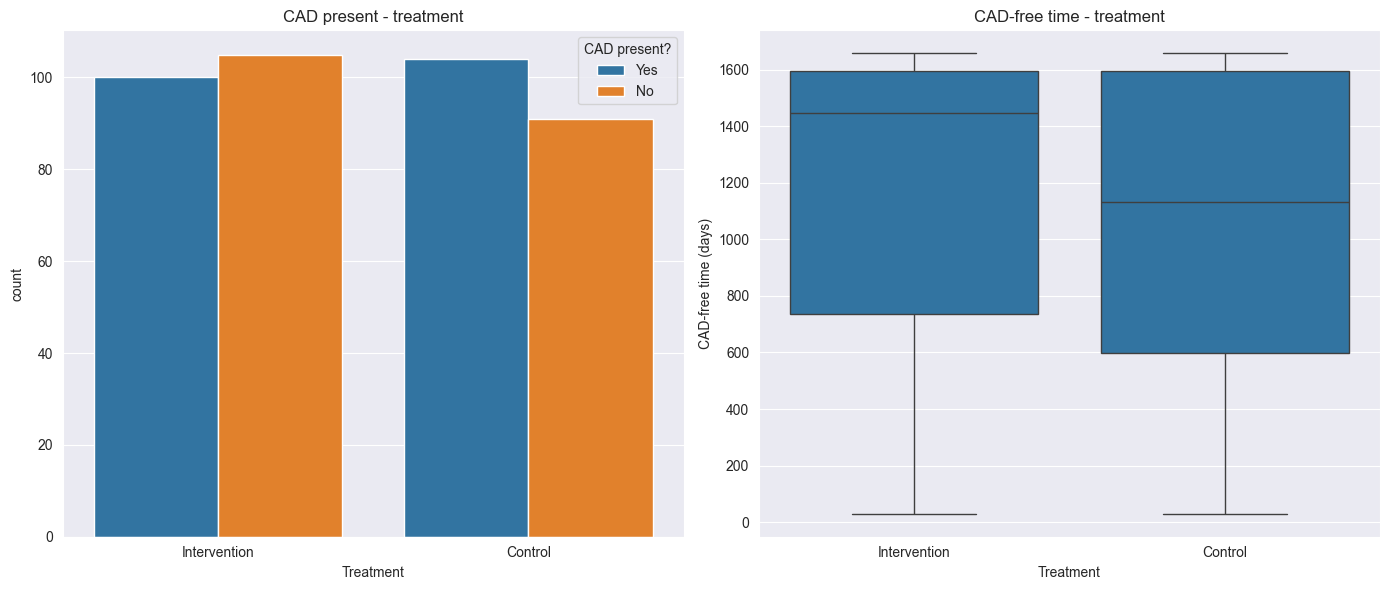

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=data, x='Treatment', hue='CAD present?', ax=axes[0]).set_title('CAD present - treatment')

# 2. Box plot: Czas wolny od CAD w podziale na grupy (Treatment)
sns.boxplot(data=data, x='Treatment', y='CAD-free time (days)', ax=axes[1]).set_title('CAD-free time - treatment')

plt.tight_layout()
plt.show()

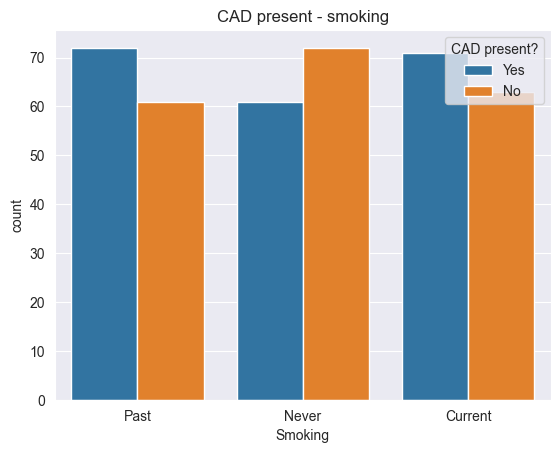

In [51]:
sns.countplot(data=data, x='Smoking', hue='CAD present?').set_title('CAD present - smoking')
plt.show()

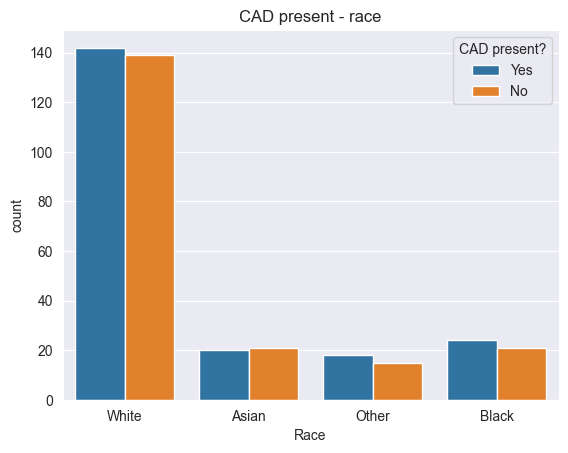

In [52]:
sns.countplot(data=data, x='Race', hue='CAD present?').set_title('CAD present - race')
plt.show()

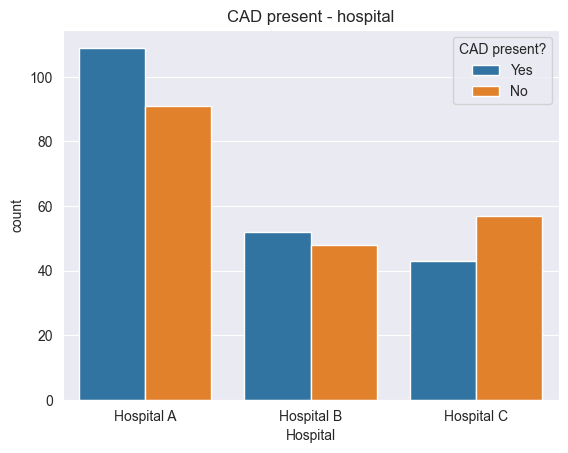

In [53]:
sns.countplot(data=data, x='Hospital', hue='CAD present?').set_title('CAD present - hospital')
plt.show()

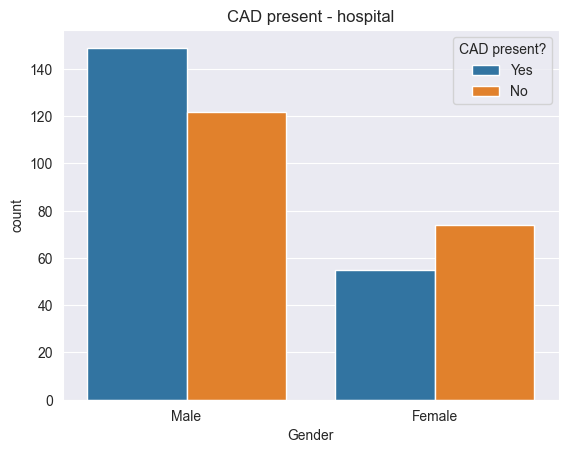

In [54]:
sns.countplot(data=data, x='Gender', hue='CAD present?').set_title('CAD present - hospital')
plt.show()

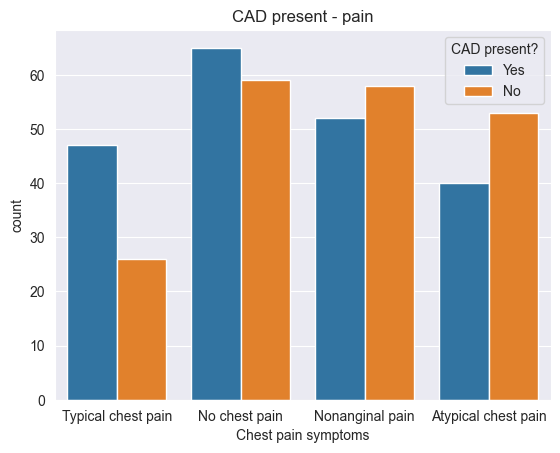

In [55]:
sns.countplot(data=data, x='Chest pain symptoms', hue='CAD present?').set_title('CAD present - pain')
plt.show()

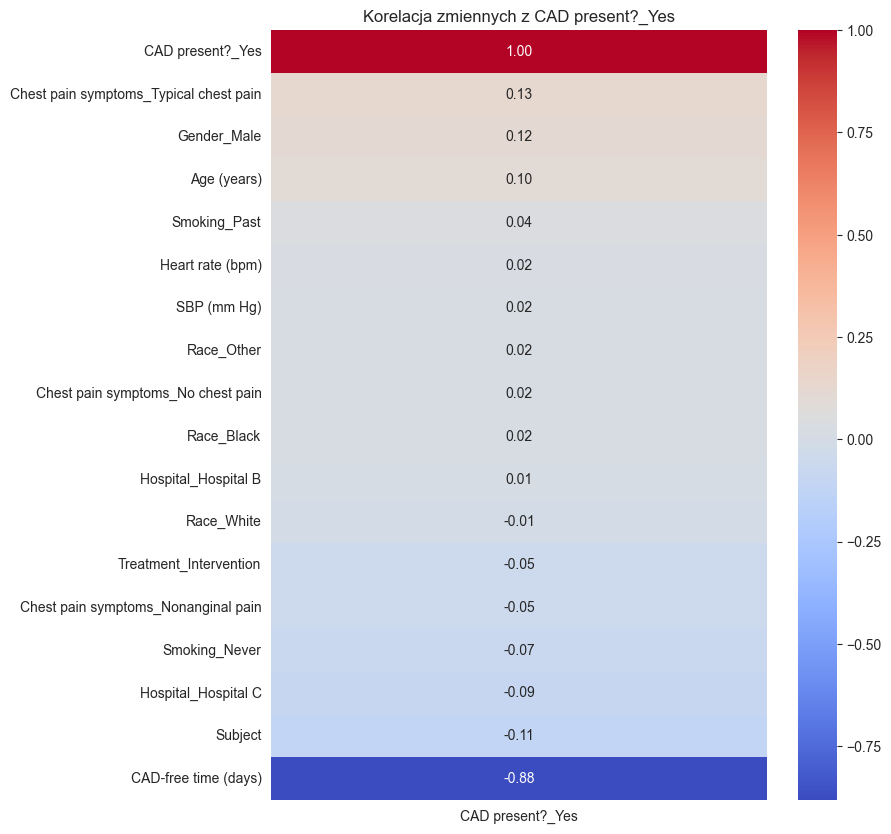

In [56]:
df_numeric = pd.get_dummies(data, drop_first=True)

target_col = [col for col in df_numeric.columns if 'CAD present?' in col][0]
correlations = df_numeric.corr()[target_col].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f"Korelacja zmiennych z {target_col}")
plt.show()

## Wnioski
Największy wpływ na CAD z danych ma płeć (bycie mężczyzną), ból w piersi, wiek,  bardzo lekki wypływ daje nam treatment intervention

# Porównanie grupy kontrolnej i interwencyjnej
Robimy to aby potem stwierdzić że tylko treatment ma wpływ na CAD !

In [62]:
age_control = data[data['Treatment'] == 'Control']['Age (years)']
age_intervention = data[data['Treatment'] == 'Intervention']['Age (years)']

t_stat, p_val = stats.ttest_ind(age_control, age_intervention, equal_var=False)

print(f"Statystyka t: {t_stat:.4f}")
print(f"Wartość p: {p_val:.4f}")

Statystyka t: -0.8467
Wartość p: 0.3976


In [64]:
contingency_table = pd.crosstab(data['Treatment'], data['Gender'])

print("Tabela liczebności (Płeć vs Grupa):")
print(contingency_table)
print("-" * 30)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Statystyka Chi2: {chi2:.4f}")
print(f"Wartość p: {p:.4f}")
print(f"Stopnie swobody: {dof}")

Tabela liczebności (Płeć vs Grupa):
Gender        Female  Male
Treatment                 
Control           54   141
Intervention      75   130
------------------------------
Statystyka Chi2: 3.2218
Wartość p: 0.0727
Stopnie swobody: 1


In [65]:
contingency_table = pd.crosstab(data['Treatment'], data['Smoking'])

print("Tabela liczebności (Smoking vs Grupa):")
print(contingency_table)
print("-" * 30)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Statystyka Chi2: {chi2:.4f}")
print(f"Wartość p: {p:.4f}")
print(f"Stopnie swobody: {dof}")

Tabela liczebności (Smoking vs Grupa):
Smoking       Current  Never  Past
Treatment                         
Control            67     68    60
Intervention       67     65    73
------------------------------
Statystyka Chi2: 1.0890
Wartość p: 0.5801
Stopnie swobody: 2


In [66]:
contingency_table = pd.crosstab(data['Treatment'], data['Race'])

print("Tabela liczebności (Race vs Grupa):")
print(contingency_table)
print("-" * 30)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Statystyka Chi2: {chi2:.4f}")
print(f"Wartość p: {p:.4f}")
print(f"Stopnie swobody: {dof}")

Tabela liczebności (Race vs Grupa):
Race          Asian  Black  Other  White
Treatment                               
Control          21     18     13    143
Intervention     20     27     20    138
------------------------------
Statystyka Chi2: 3.1502
Wartość p: 0.3690
Stopnie swobody: 3


dla kolumn:
- age: p=0.3976 i t=-0.8467 - mówi że nie ma różnic między grupami - test t studenta
- gender: p=0.0727 chi2=3.2218 stopnie swobody 1 - mówi że nie ma różnic między grupami - test chi kwadrat
- smoking: p=0.5801 chi2=1.089 stopnie swobody 2 - mówi że nie ma różnciy między grupami - test chi kwadrat
- race: p=0.3690 chi2=3.1502 stopnie swobody 3 - mówi że nie ma różnicy między grupami - test chi kwadrat

# Odds Ratio
Sprawdzimy czy treatment ma wpływ na CAD

In [67]:
table = pd.crosstab(data['Treatment'], data['CAD present?'])

res = stats.fisher_exact(table, alternative='two-sided')
odds_ratio = res[0]
p_value = res[1]

try:
    ci_low, ci_high = stats.contingency.odds_ratio(table).confidence_interval(confidence_level=0.95)
except AttributeError:
    ci_low, ci_high = "N/A", "N/A"

print(f"Odds Ratio (OR): {odds_ratio:.4f}")
print(f"Wartość p: {p_value:.4f}")
print(f"95% Przedział Ufności (CI): [{ci_low}, {ci_high}]")

Odds Ratio (OR): 0.8333
Wartość p: 0.3698
95% Przedział Ufności (CI): [0.5520216021825803, 1.2578097439460199]


Mimo że zaobserwowano trend sugerujący niższe szanse na wystąpienie CAD w grupie interwencyjnej ($OR = 0.83$), różnica ta nie osiągnęła istotności statystycznej ($p = 0.37$; $95\%\ CI: 0.55–1.26$). Na podstawie obecnych danych nie można potwierdzić skuteczności interwencji w zapobieganiu CAD

In [71]:
import pandas as pd
from scipy import stats

# 1. Przygotowanie grup wiekowych
data['Age_Group'] = data['Age (years)'].apply(lambda x: '>60' if x >= 60 else '<60')

factors = ['Smoking', 'Gender', 'Age_Group']

print(f"{'Czynnik':<15} | {'Metoda':<10} | {'OR/Stat':<8} | {'p-value':<10} | {'95% CI'}")
print("-" * 75)

for factor in factors:
    table = pd.crosstab(data[factor], data['CAD present?'])

    if table.shape == (2, 2):
        res = stats.fisher_exact(table, alternative='two-sided')
        or_val = res[0]
        p_val = res[1]
        metoda = "Fisher"

        try:
            ci = stats.contingency.odds_ratio(table).confidence_interval()
            ci_str = f"[{ci[0]:.2f}, {ci[1]:.2f}]"
        except:
            ci_str = "N/A"
    else:
        chi2, p_val, dof, expected = stats.chi2_contingency(table)
        or_val = chi2 
        ci_str = "N/A"
        metoda = "Chi2"

    print(f"{factor:<15} | {metoda:<10} | {or_val:<8.4f} | {p_val:<10.4f} | {ci_str}")

Czynnik         | Metoda     | OR/Stat  | p-value    | 95% CI
---------------------------------------------------------------------------
Smoking         | Chi2       | 2.1380   | 0.3433     | N/A
Gender          | Fisher     | 1.6432   | 0.0246     | [1.05, 2.57]
Age_Group       | Fisher     | 2.6440   | 0.2760     | [0.43, 28.01]
